#Tahap 1 — Import Library

In [1]:
# ============================================================
# STEP 1: IMPORT LIBRARY
# ============================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Modeling
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

# Evaluasi
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report)

# Model Saving
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ Semua library berhasil diimport!")
print(f"📦 Pandas     : {pd.__version__}")
print(f"📦 Numpy      : {np.__version__}")
print(f"📦 Sklearn    : {__import__('sklearn').__version__}")

✅ Semua library berhasil diimport!
📦 Pandas     : 2.3.3
📦 Numpy      : 1.26.4
📦 Sklearn    : 1.7.2


#Tahap 2 — Load Dataset dan Melihat Struktur Data

In [2]:
# ============================================================
# STEP 2: LOAD DATASET & CEK AWAL
# ============================================================

# Load dataset
df = pd.read_csv('student_dropout_dataset_v3.csv')

# --- 2.1 Cek dimensi dataset ---
print("=" * 50)
print("📊 INFORMASI DASAR DATASET")
print("=" * 50)
print(f"🔢 Jumlah Baris    : {df.shape[0]:,}")
print(f"🔢 Jumlah Kolom    : {df.shape[1]}")
print(f"🎯 Target Variable : Dropout")

# --- 2.2 Cek 5 baris pertama ---
print("\n📋 5 BARIS PERTAMA DATASET:")
print("-" * 50)
display(df.head())

# --- 2.3 Tipe data & missing values ---
print("\n📋 INFO TIPE DATA & MISSING VALUES:")
print("-" * 50)
df.info()

# --- 2.4 Distribusi target variable ---
print("\n🎯 DISTRIBUSI TARGET VARIABLE (Dropout):")
print("-" * 50)
dropout_counts = df['Dropout'].value_counts()
dropout_pct    = df['Dropout'].value_counts(normalize=True) * 100
print(f"  Tidak Dropout (0) : {dropout_counts[0]:,} ({dropout_pct[0]:.2f}%)")
print(f"  Dropout       (1) : {dropout_counts[1]:,} ({dropout_pct[1]:.2f}%)")

# --- 2.5 Cek missing values per kolom ---
print("\n⚠️  MISSING VALUES PER KOLOM:")
print("-" * 50)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct.round(2)
}).query('`Missing Count` > 0')
print(missing_df)

📊 INFORMASI DASAR DATASET
🔢 Jumlah Baris    : 10,000
🔢 Jumlah Kolom    : 19
🎯 Target Variable : Dropout

📋 5 BARIS PERTAMA DATASET:
--------------------------------------------------


,Student_ID,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,CGPA,Semester,Department,Parental_Education,Dropout
0,1,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,0.90,Year 1,Arts,High School,0
1,2,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,1.19,Year 3,Engineering,Bachelor,1
2,3,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,1.32,Year 1,Arts,Master,0
3,4,24.4,Male,NaN,Yes,NaN,82.2,2,38.6,No,No,NaN,1.78,1.77,1.77,Year 1,CS,High School,1
4,5,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,0.87,Year 4,Business,Bachelor,0



📋 INFO TIPE DATA & MISSING VALUES:
--------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             10000 non-null  int64  
 1   Age                    10000 non-null  float64
 2   Gender                 10000 non-null  object 
 3   Family_Income          9500 non-null   float64
 4   Internet_Access        10000 non-null  object 
 5   Study_Hours_per_Day    9500 non-null   float64
 6   Attendance_Rate        10000 non-null  float64
 7   Assignment_Delay_Days  10000 non-null  int64  
 8   Travel_Time_Minutes    10000 non-null  float64
 9   Part_Time_Job          10000 non-null  object 
 10  Scholarship            10000 non-null  object 
 11  Stress_Index           9500 non-null   float64
 12  GPA                    10000 non-null  float64
 13  Semester_GPA        

#STEP 3 — Statistik Deskriptif & EDA

📊 STATISTIK DESKRIPTIF - FITUR NUMERIK


,Student_ID,Age,Family_Income,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Stress_Index,GPA,Semester_GPA,CGPA,Dropout
count,10000.00,10000.00,9500.00,9500.00,10000.00,10000.00,10000.00,9500.00,10000.00,10000.00,10000.00,10000.00
mean,5000.50,21.03,38377.25,4.01,81.74,1.80,30.18,5.51,2.31,2.30,2.30,0.24
std,2886.90,2.14,20496.23,1.30,8.22,1.34,11.92,1.77,1.06,1.07,1.07,0.42
min,1.00,17.00,25000.00,0.50,38.20,0.00,5.00,1.00,0.00,0.00,0.00,0.00
25%,2500.75,19.50,25000.00,3.16,76.40,1.00,21.90,4.30,1.55,1.52,1.52,0.00
50%,5000.50,21.00,29740.50,4.00,81.80,2.00,30.20,5.50,2.35,2.35,2.35,0.00
75%,7500.25,22.50,44520.00,4.87,87.30,3.00,38.40,6.70,3.12,3.15,3.15,0.00
max,10000.00,29.60,316601.00,8.98,100.00,8.00,74.90,10.00,4.00,4.00,4.00,1.00


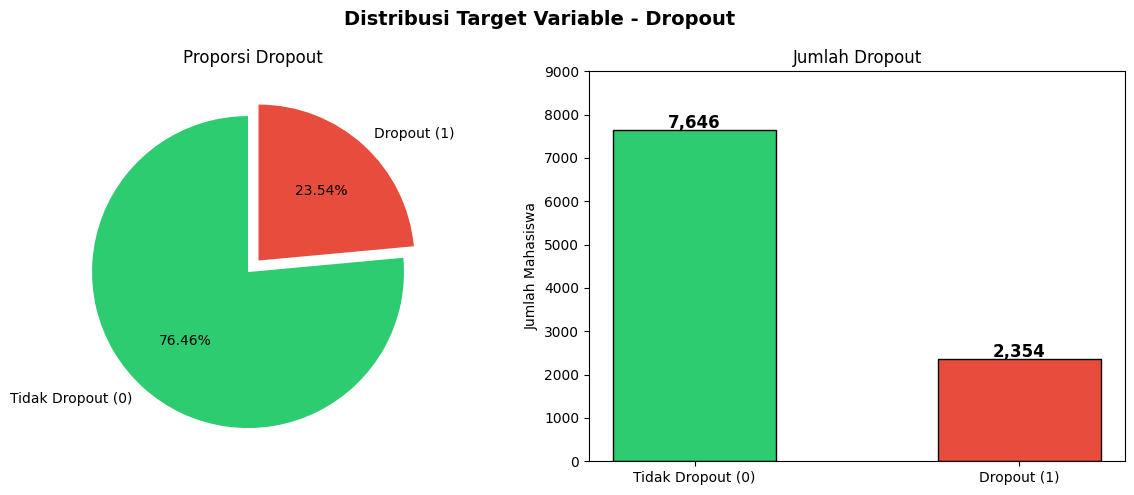

✅ Plot 1 - Distribusi Target Variable selesai!


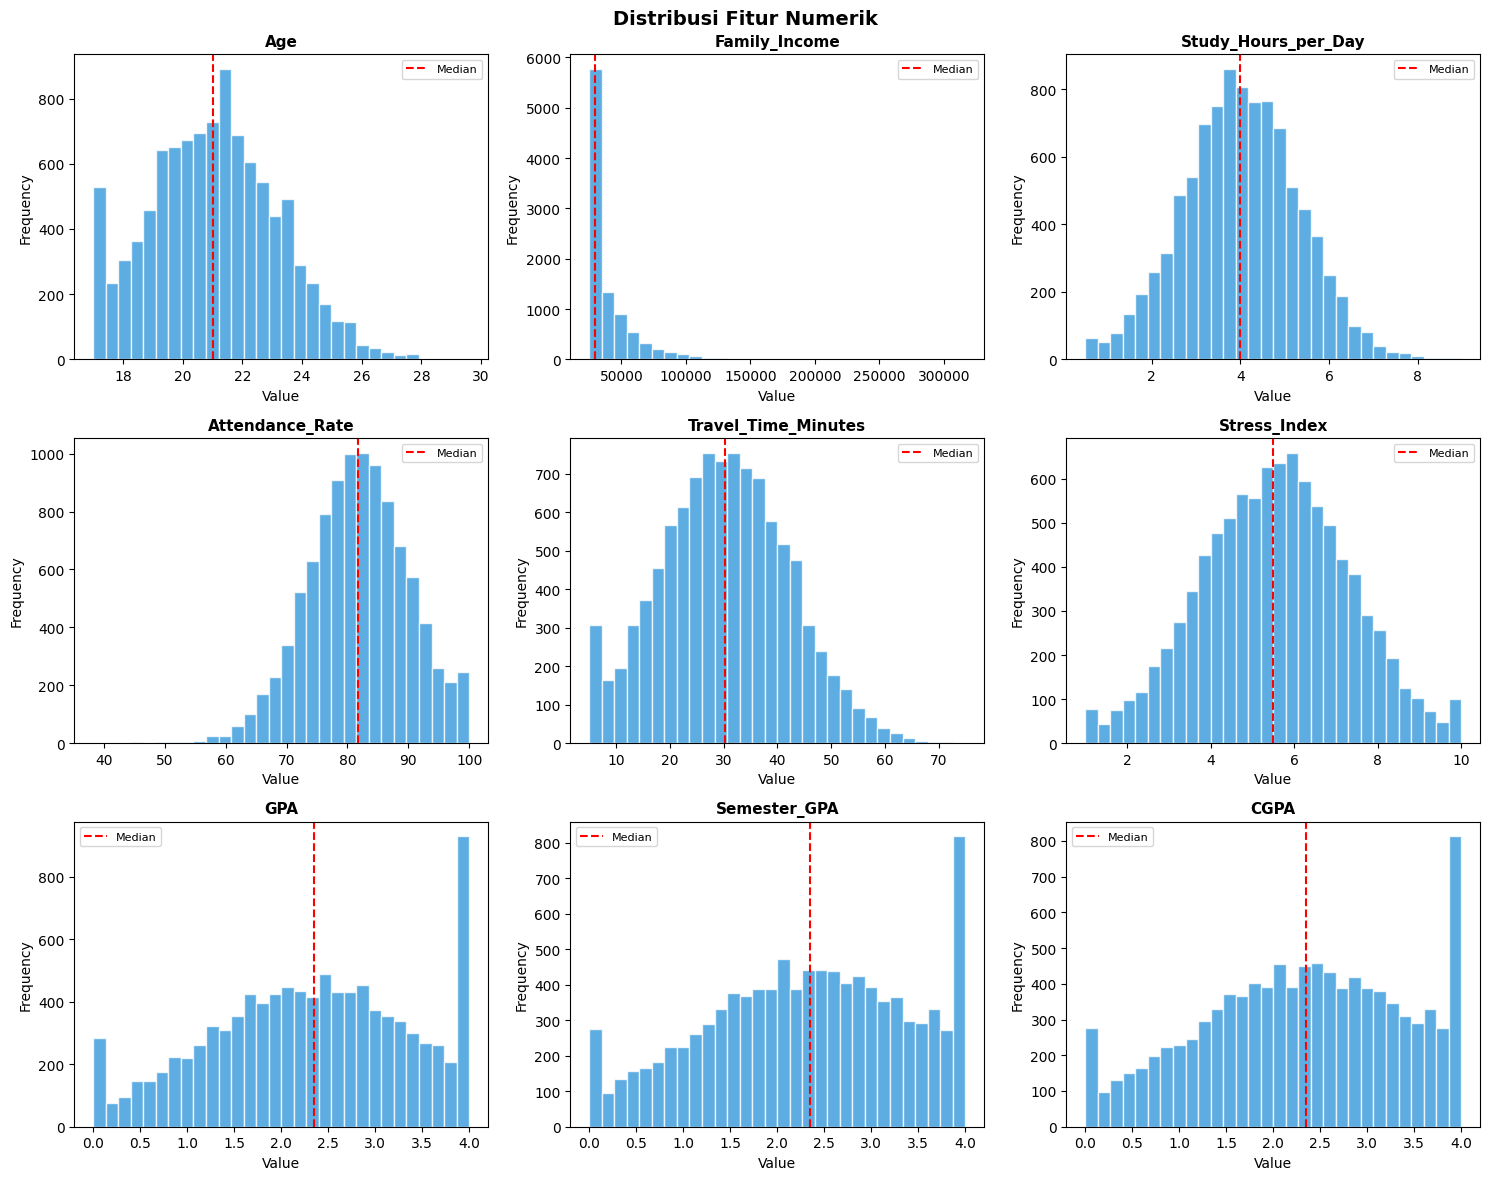

✅ Plot 2 - Distribusi Fitur Numerik selesai!


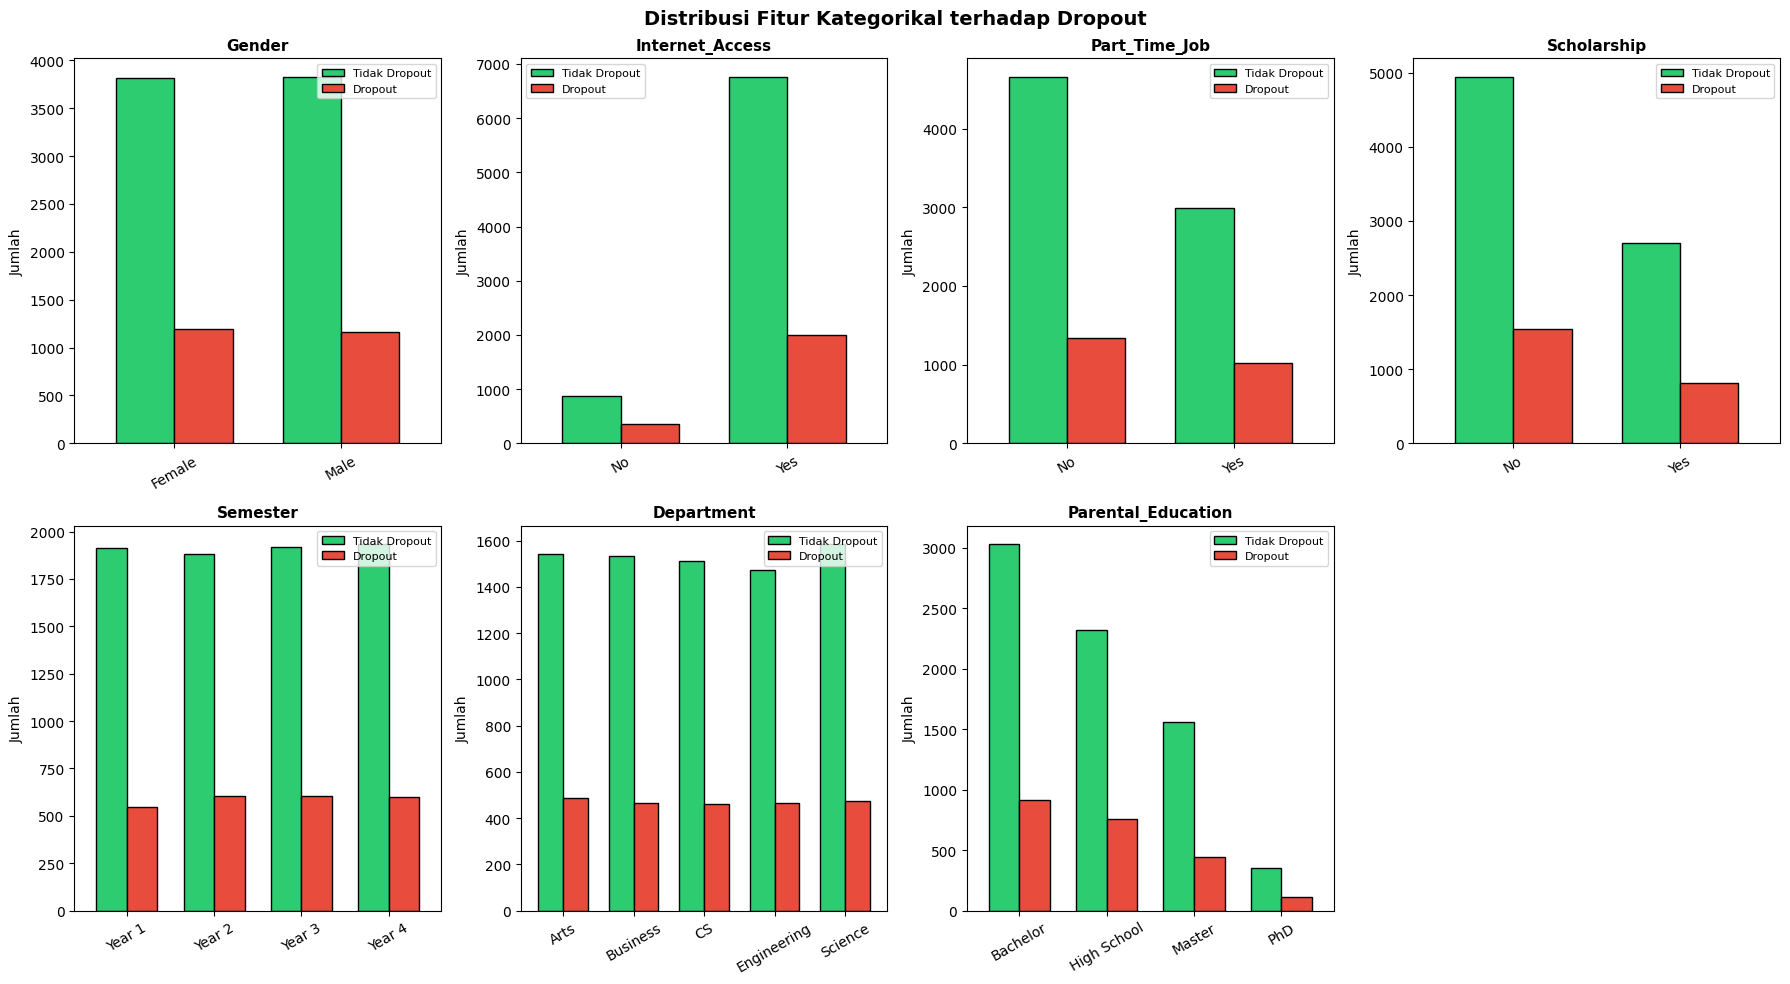

✅ Plot 3 - Distribusi Fitur Kategorikal selesai!


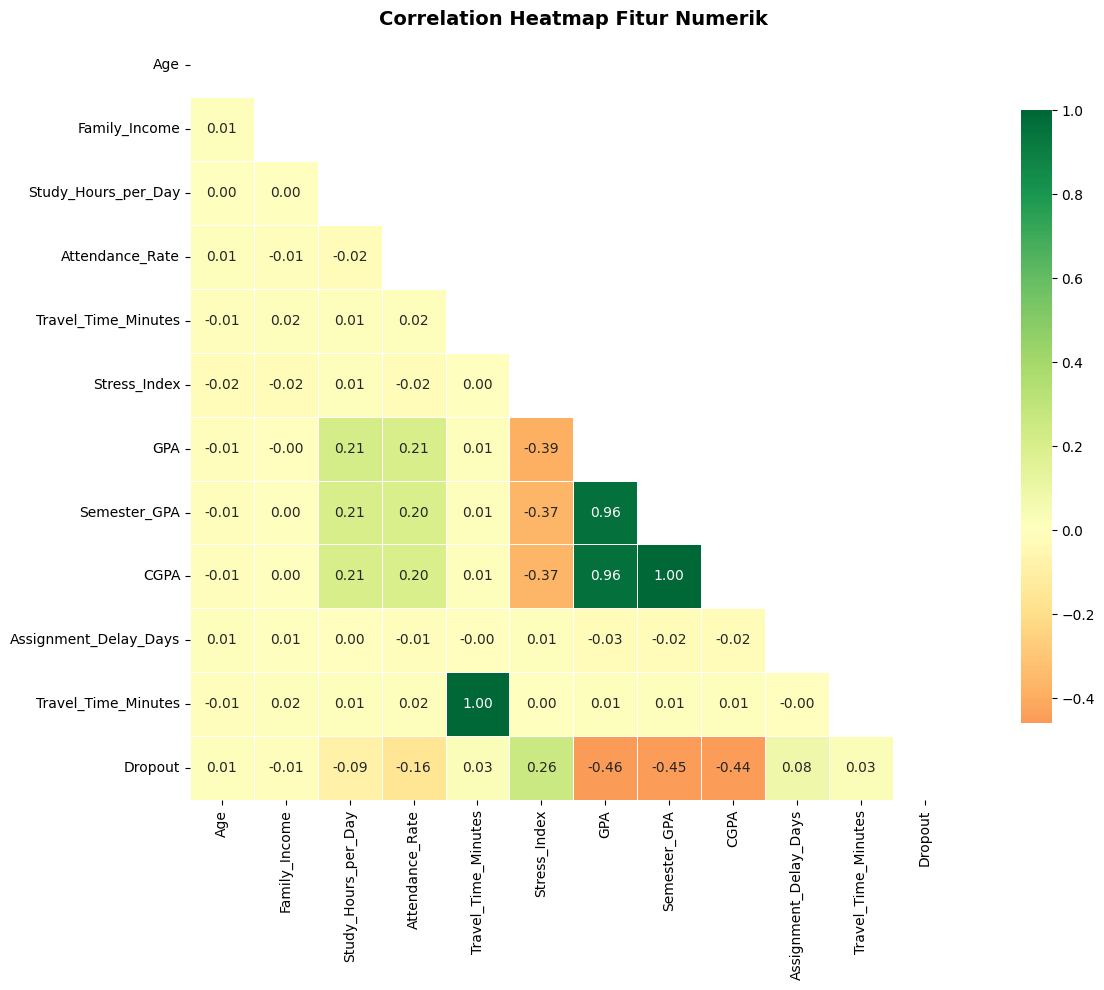

✅ Plot 4 - Correlation Heatmap selesai!


In [3]:
# ============================================================
# STEP 3: STATISTIK DESKRIPTIF & EDA
# ============================================================

# --- 3.1 Statistik Deskriptif ---
print("=" * 50)
print("📊 STATISTIK DESKRIPTIF - FITUR NUMERIK")
print("=" * 50)
display(df.describe().round(2))

# --- 3.2 Distribusi Target Variable (Visualisasi) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Distribusi Target Variable - Dropout', fontsize=14, fontweight='bold')

# Pie Chart
colors = ['#2ecc71', '#e74c3c']
axes[0].pie(df['Dropout'].value_counts(),
            labels=['Tidak Dropout (0)', 'Dropout (1)'],
            autopct='%1.2f%%',
            colors=colors,
            startangle=90,
            explode=(0.05, 0.05))
axes[0].set_title('Proporsi Dropout')

# Bar Chart
dropout_counts = df['Dropout'].value_counts()
bars = axes[1].bar(['Tidak Dropout (0)', 'Dropout (1)'],
                    dropout_counts.values,
                    color=colors, edgecolor='black', width=0.5)
for bar, val in zip(bars, dropout_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f'{val:,}', ha='center', fontsize=12, fontweight='bold')
axes[1].set_title('Jumlah Dropout')
axes[1].set_ylabel('Jumlah Mahasiswa')
axes[1].set_ylim(0, 9000)
plt.tight_layout()
plt.savefig('plot_01_distribusi_target.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 1 - Distribusi Target Variable selesai!")

# --- 3.3 Distribusi Fitur Numerik ---
num_cols = ['Age', 'Family_Income', 'Study_Hours_per_Day',
            'Attendance_Rate', 'Travel_Time_Minutes',
            'Stress_Index', 'GPA', 'Semester_GPA', 'CGPA']

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
fig.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='#3498db',
                 edgecolor='white', alpha=0.8)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')
    axes[i].axvline(df[col].median(), color='red',
                    linestyle='--', linewidth=1.5, label='Median')
    axes[i].legend(fontsize=8)

plt.tight_layout()
plt.savefig('plot_02_distribusi_numerik.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 2 - Distribusi Fitur Numerik selesai!")

# --- 3.4 Distribusi Fitur Kategorikal ---
cat_cols = ['Gender', 'Internet_Access', 'Part_Time_Job',
            'Scholarship', 'Semester', 'Department', 'Parental_Education']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
fig.suptitle('Distribusi Fitur Kategorikal terhadap Dropout',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ct = pd.crosstab(df[col], df['Dropout'])
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'],
            edgecolor='black', width=0.7)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Jumlah')
    axes[i].legend(['Tidak Dropout', 'Dropout'], fontsize=8)
    axes[i].tick_params(axis='x', rotation=30)

# Sembunyikan subplot kosong
axes[-1].set_visible(False)
plt.tight_layout()
plt.savefig('plot_03_distribusi_kategorikal.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 3 - Distribusi Fitur Kategorikal selesai!")

# --- 3.5 Correlation Heatmap ---
plt.figure(figsize=(14, 10))
corr_matrix = df[num_cols + ['Assignment_Delay_Days',
                              'Travel_Time_Minutes', 'Dropout']].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0,
            linewidths=0.5,
            square=True,
            cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap Fitur Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_04_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 4 - Correlation Heatmap selesai!")

# STEP 4 — Data Preparation

In [4]:
# ============================================================
# STEP 4: DATA PREPARATION
# ============================================================

# Salin dataset agar original tidak berubah
df_clean = df.copy()

# --- 4.1 Drop kolom tidak relevan ---
# Student_ID tidak memiliki nilai prediktif
# CGPA highly correlated dengan GPA & Semester_GPA (0.96) → drop untuk hindari multikolinearitas
drop_cols = ['Student_ID', 'CGPA']
df_clean = df_clean.drop(columns=drop_cols)

print("=" * 50)
print("🗑️  KOLOM YANG DI-DROP:")
print("=" * 50)
for col in drop_cols:
    print(f"  ❌ {col}")

# --- 4.2 Handling Missing Values ---
print("\n" + "=" * 50)
print("🔧 HANDLING MISSING VALUES")
print("=" * 50)

# Numerik → Median
num_missing = ['Family_Income', 'Study_Hours_per_Day', 'Stress_Index']
for col in num_missing:
    median_val = df_clean[col].median()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"  ✅ {col:<25} → diisi median: {median_val:.2f}")

# Kategorikal → Modus
cat_missing = ['Parental_Education']
for col in cat_missing:
    mode_val = df_clean[col].mode()[0]
    df_clean[col] = df_clean[col].fillna(mode_val)
    print(f"  ✅ {col:<25} → diisi modus: '{mode_val}'")

# Verifikasi
print(f"\n📋 Total missing values setelah handling: {df_clean.isnull().sum().sum()}")
print(f"📐 Shape dataset: {df_clean.shape}")

🗑️  KOLOM YANG DI-DROP:
  ❌ Student_ID
  ❌ CGPA

🔧 HANDLING MISSING VALUES
  ✅ Family_Income             → diisi median: 29740.50
  ✅ Study_Hours_per_Day       → diisi median: 4.00
  ✅ Stress_Index              → diisi median: 5.50
  ✅ Parental_Education        → diisi modus: 'Bachelor'

📋 Total missing values setelah handling: 0
📐 Shape dataset: (10000, 17)


📦 DETEKSI OUTLIER - METODE IQR


,Fitur,Q1,Q3,IQR,Lower Bound,Upper Bound,Jumlah Outlier,Persentase (%)
0,Age,19.50,22.50,3.00,15.00,27.00,33,0.33
1,Family_Income,25000.00,43361.75,18361.75,-2542.62,70904.38,683,6.83
2,Study_Hours_per_Day,3.21,4.81,1.60,0.81,7.21,138,1.38
3,Attendance_Rate,76.40,87.30,10.90,60.05,103.65,57,0.57
4,Assignment_Delay_Days,1.00,3.00,2.00,-2.00,6.00,25,0.25
5,Travel_Time_Minutes,21.90,38.40,16.50,-2.85,63.15,25,0.25
6,Stress_Index,4.40,6.60,2.20,1.10,9.90,137,1.37
7,GPA,1.55,3.12,1.57,-0.80,5.48,0,0.00
8,Semester_GPA,1.52,3.15,1.63,-0.92,5.60,0,0.00



⚠️  Total outlier terdeteksi: 1098


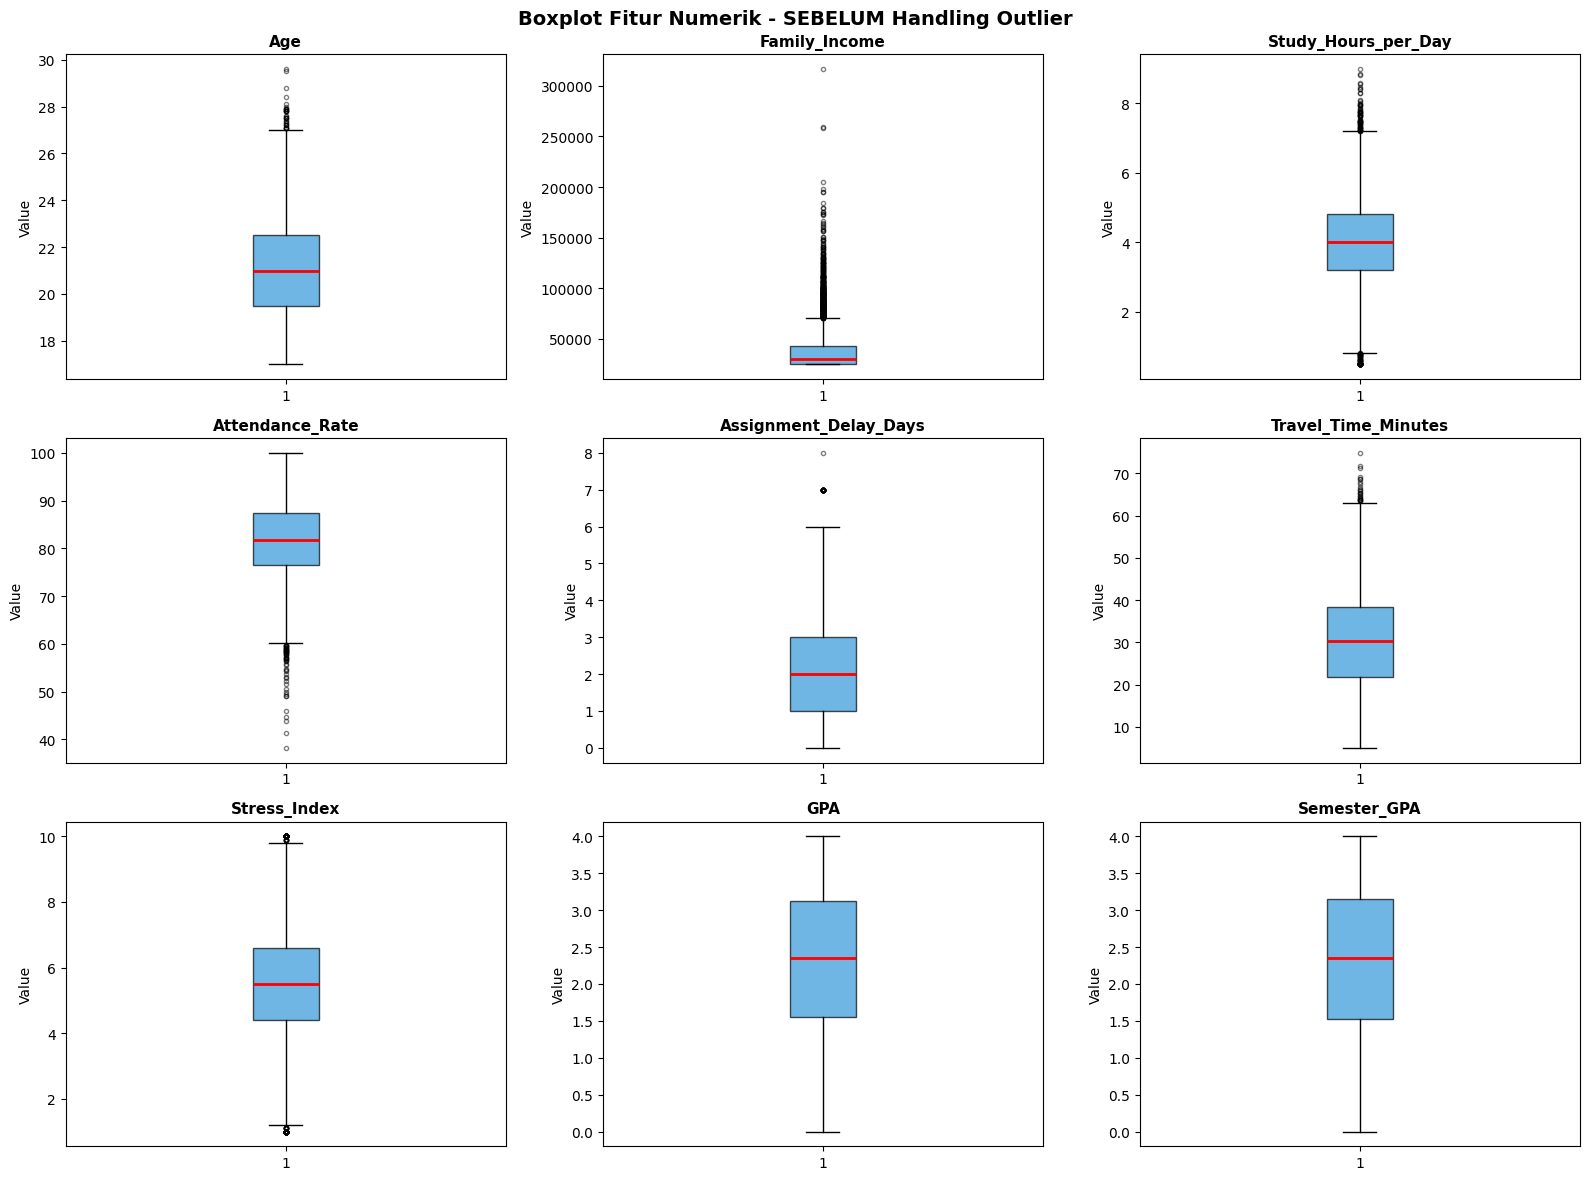

✅ Plot 5 - Boxplot SEBELUM outlier handling selesai!

🔧 PENANGANAN OUTLIER - CAPPING (WINSORIZING)
  ✅ Age                       → outlier: 33 → 0 (setelah capping)
  ✅ Family_Income             → outlier: 683 → 0 (setelah capping)
  ✅ Study_Hours_per_Day       → outlier: 138 → 0 (setelah capping)
  ✅ Attendance_Rate           → outlier: 57 → 0 (setelah capping)
  ✅ Assignment_Delay_Days     → outlier: 25 → 0 (setelah capping)
  ✅ Travel_Time_Minutes       → outlier: 25 → 0 (setelah capping)
  ✅ Stress_Index              → outlier: 137 → 0 (setelah capping)
  ✅ GPA                       → outlier: 0 → 0 (setelah capping)
  ✅ Semester_GPA              → outlier: 0 → 0 (setelah capping)


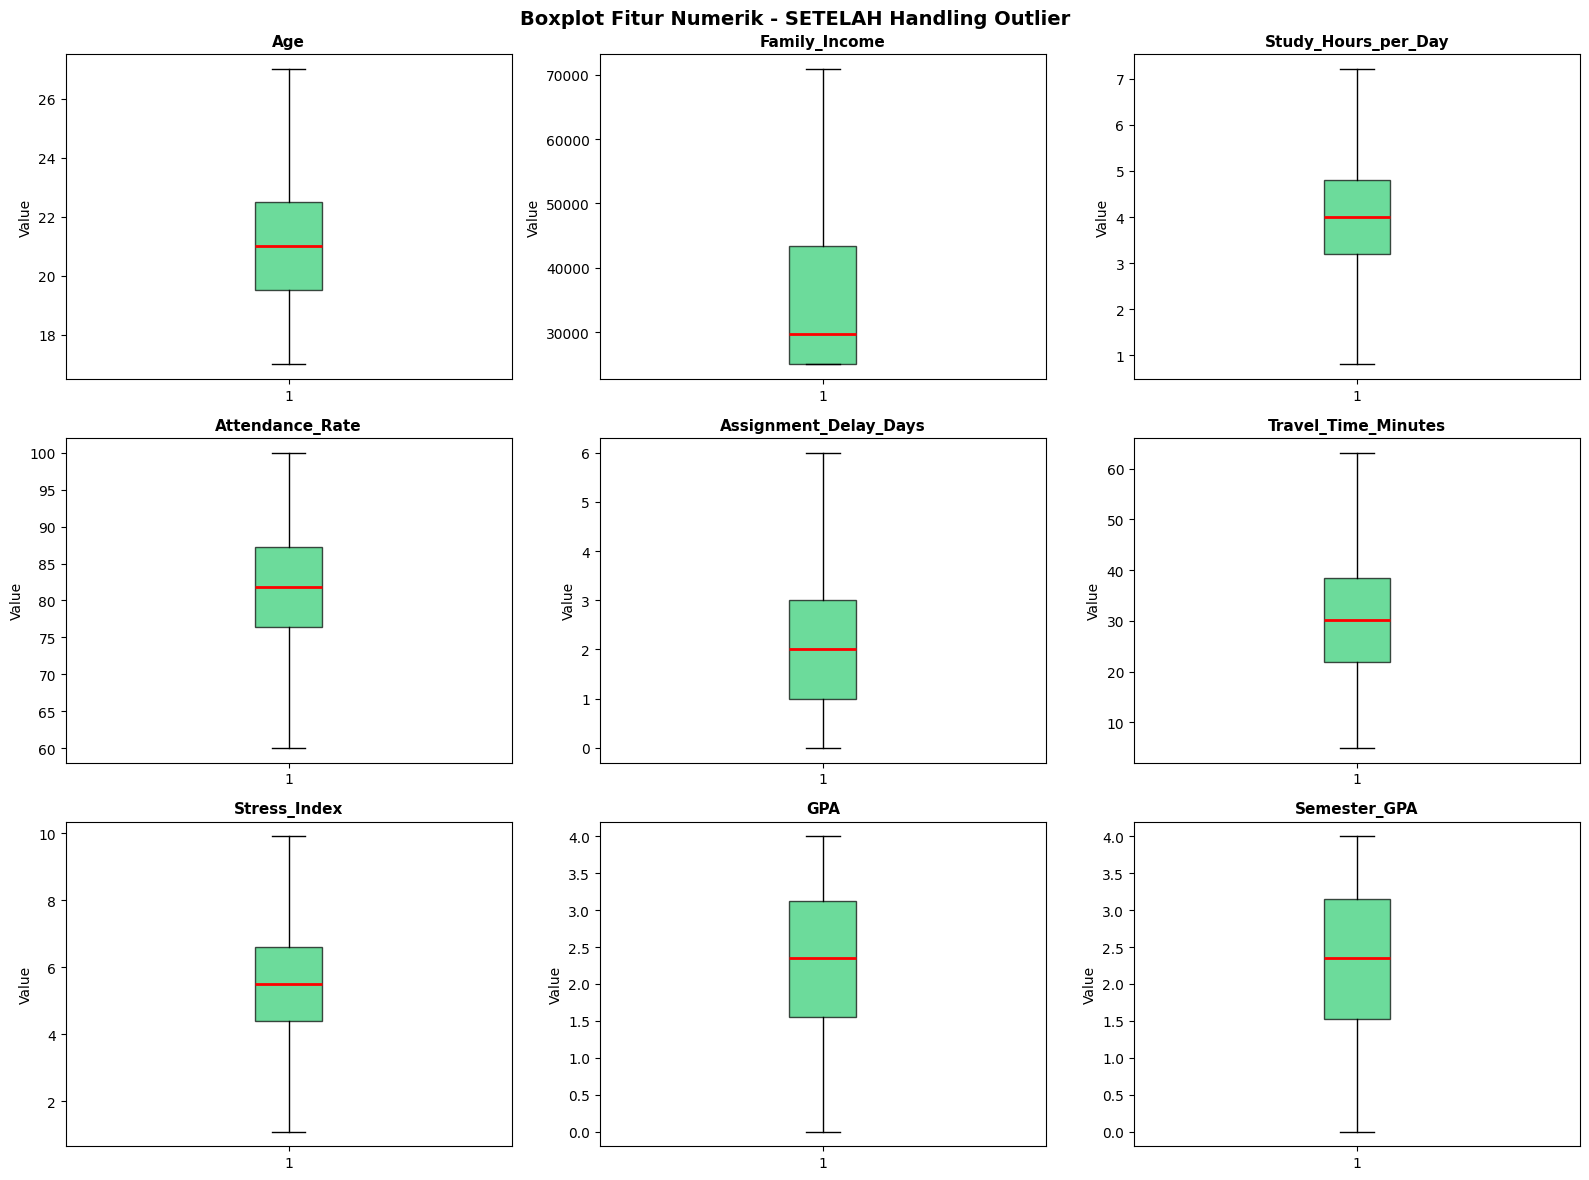

✅ Plot 6 - Boxplot SETELAH outlier handling selesai!

📐 Shape dataset final: (10000, 17)


In [5]:
# ============================================================
# STEP 4.2: DETEKSI & PENANGANAN OUTLIER (IQR METHOD)
# ============================================================

num_cols_outlier = ['Age', 'Family_Income', 'Study_Hours_per_Day',
                    'Attendance_Rate', 'Assignment_Delay_Days',
                    'Travel_Time_Minutes', 'Stress_Index',
                    'GPA', 'Semester_GPA']

print("=" * 60)
print("📦 DETEKSI OUTLIER - METODE IQR")
print("=" * 60)

outlier_summary = []
for col in num_cols_outlier:
    Q1  = df_clean[col].quantile(0.25)
    Q3  = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outlier = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    pct = (n_outlier / len(df_clean)) * 100
    outlier_summary.append({
        'Fitur': col, 'Q1': round(Q1,2), 'Q3': round(Q3,2),
        'IQR': round(IQR,2), 'Lower Bound': round(lower,2),
        'Upper Bound': round(upper,2), 'Jumlah Outlier': n_outlier,
        'Persentase (%)': round(pct,2)
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

total_outlier = outlier_df['Jumlah Outlier'].sum()
print(f"\n⚠️  Total outlier terdeteksi: {total_outlier}")

# --- Visualisasi Boxplot SEBELUM handling ---
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Boxplot Fitur Numerik - SEBELUM Handling Outlier',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(num_cols_outlier):
    axes[i].boxplot(df_clean[col].dropna(),
                    patch_artist=True,
                    boxprops=dict(facecolor='#3498db', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', color='orange',
                                   markersize=3, alpha=0.5))
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.savefig('plot_05_boxplot_before.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 5 - Boxplot SEBELUM outlier handling selesai!")

# --- Penanganan Outlier: CAPPING / WINSORIZING ---
print("\n" + "=" * 60)
print("🔧 PENANGANAN OUTLIER - CAPPING (WINSORIZING)")
print("=" * 60)

df_clean2 = df_clean.copy()
for col in num_cols_outlier:
    Q1  = df_clean2[col].quantile(0.25)
    Q3  = df_clean2[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    before = ((df_clean2[col] < lower) | (df_clean2[col] > upper)).sum()
    df_clean2[col] = df_clean2[col].clip(lower=lower, upper=upper)
    after = ((df_clean2[col] < lower) | (df_clean2[col] > upper)).sum()
    print(f"  ✅ {col:<25} → outlier: {before} → {after} (setelah capping)")

# --- Visualisasi Boxplot SETELAH handling ---
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
fig.suptitle('Boxplot Fitur Numerik - SETELAH Handling Outlier',
             fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(num_cols_outlier):
    axes[i].boxplot(df_clean2[col].dropna(),
                    patch_artist=True,
                    boxprops=dict(facecolor='#2ecc71', alpha=0.7),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', color='orange',
                                   markersize=3, alpha=0.5))
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.savefig('plot_06_boxplot_after.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 6 - Boxplot SETELAH outlier handling selesai!")
print(f"\n📐 Shape dataset final: {df_clean2.shape}")

In [6]:
# ============================================================
# STEP 4.3: PENGECEKAN DATA DUPLIKAT
# ============================================================

print("=" * 50)
print("🔍 PENGECEKAN DATA DUPLIKAT")
print("=" * 50)

# Cek jumlah duplikat
n_duplikat = df_clean.duplicated().sum()
print(f"\n📋 Total baris duplikat : {n_duplikat}")
print(f"📋 Total baris sebelum  : {df_clean.shape[0]:,}")

if n_duplikat > 0:
    print(f"\n⚠️  Ditemukan {n_duplikat} baris duplikat!")
    print("\n📋 Contoh baris duplikat:")
    display(df_clean[df_clean.duplicated(keep='first')].head())

    # Hapus duplikat
    df_clean = df_clean.drop_duplicates(keep='first').reset_index(drop=True)
    print(f"\n✅ Duplikat berhasil dihapus!")
    print(f"📋 Total baris setelah : {df_clean.shape[0]:,}")
else:
    print(f"\n✅ Tidak ada data duplikat ditemukan!")
    print(f"📋 Dataset tetap      : {df_clean.shape[0]:,} baris")

print(f"\n📐 Shape dataset: {df_clean.shape}")

🔍 PENGECEKAN DATA DUPLIKAT

📋 Total baris duplikat : 0
📋 Total baris sebelum  : 10,000

✅ Tidak ada data duplikat ditemukan!
📋 Dataset tetap      : 10,000 baris

📐 Shape dataset: (10000, 17)


In [7]:
# ============================================================
# STEP 4.4: SINKRONISASI DATAFRAME & ENCODING
# ============================================================

# Sinkronisasi: gunakan df_clean2 sebagai dataframe utama
# (sudah: drop kolom, missing values, outlier capping, cek duplikat)
df_prep = df_clean2.copy()

print("=" * 55)
print("📋 STATUS DATAFRAME SEBELUM ENCODING")
print("=" * 55)
print(f"Shape : {df_prep.shape}")
print(f"\nTipe data per kolom:")
print(df_prep.dtypes)

# Cek kolom kategorikal
cat_cols = df_prep.select_dtypes(include='object').columns.tolist()
print(f"\n🔤 Kolom Kategorikal ({len(cat_cols)}):")
for col in cat_cols:
    print(f"  → {col}: {df_prep[col].unique()}")

# ============================================================
# ENCODING KATEGORIKAL
# ============================================================
print("\n" + "=" * 55)
print("🔧 ENCODING VARIABEL KATEGORIKAL")
print("=" * 55)

df_encoded = df_prep.copy()

# --- Label Encoding: Binary (2 kategori) ---
label_cols = ['Gender', 'Internet_Access', 'Part_Time_Job', 'Scholarship']
le = LabelEncoder()

print("\n📌 Label Encoding (Binary):")
for col in label_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])
    mapping = dict(zip(le.classes_, le.transform(le.classes_)))
    print(f"  ✅ {col:<20} → {mapping}")

# --- One-Hot Encoding: Multi-kelas ---
ohe_cols = ['Semester', 'Department', 'Parental_Education']
print(f"\n📌 One-Hot Encoding (Multi-kelas):")
print(f"  Kolom: {ohe_cols}")

df_encoded = pd.get_dummies(df_encoded,
                             columns=ohe_cols,
                             drop_first=False,
                             dtype=int)

# Verifikasi
print(f"\n✅ Encoding selesai!")
print(f"📐 Shape sebelum encoding : {df_prep.shape}")
print(f"📐 Shape setelah encoding : {df_encoded.shape}")
print(f"\n📋 Kolom setelah encoding:")
for col in df_encoded.columns.tolist():
    print(f"  → {col}")

📋 STATUS DATAFRAME SEBELUM ENCODING
Shape : (10000, 17)

Tipe data per kolom:
Age                      float64
Gender                    object
Family_Income            float64
Internet_Access           object
Study_Hours_per_Day      float64
Attendance_Rate          float64
Assignment_Delay_Days      int64
Travel_Time_Minutes      float64
Part_Time_Job             object
Scholarship               object
Stress_Index             float64
GPA                      float64
Semester_GPA             float64
Semester                  object
Department                object
Parental_Education        object
Dropout                    int64
dtype: object

🔤 Kolom Kategorikal (7):
  → Gender: ['Male' 'Female']
  → Internet_Access: ['Yes' 'No']
  → Part_Time_Job: ['Yes' 'No']
  → Scholarship: ['No' 'Yes']
  → Semester: ['Year 1' 'Year 3' 'Year 4' 'Year 2']
  → Department: ['Arts' 'Engineering' 'CS' 'Business' 'Science']
  → Parental_Education: ['High School' 'Bachelor' 'Master' 'PhD']

🔧 ENCODING 

In [8]:
# ============================================================
# STEP 4.5: PISAH FITUR & TARGET + FEATURE SCALING
# ============================================================

print("=" * 55)
print("✂️  PISAH FITUR (X) & TARGET (y)")
print("=" * 55)

# Pisah X dan y
X = df_encoded.drop(columns=['Dropout'])
y = df_encoded['Dropout']

print(f"📐 Shape X (Fitur) : {X.shape}")
print(f"📐 Shape y (Target): {y.shape}")
print(f"\n🎯 Distribusi Target:")
print(f"  Tidak Dropout (0) : {(y==0).sum():,} ({(y==0).mean()*100:.2f}%)")
print(f"  Dropout       (1) : {(y==1).sum():,} ({(y==1).mean()*100:.2f}%)")

# ============================================================
# STEP 4.6: TRAIN-TEST SPLIT (80:20)
# ============================================================
print("\n" + "=" * 55)
print("✂️  TRAIN-TEST SPLIT (80:20)")
print("=" * 55)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y        # jaga proporsi kelas
)

print(f"📊 Data Training   : {X_train.shape[0]:,} baris ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"📊 Data Testing    : {X_test.shape[0]:,} baris ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"\n🎯 Distribusi y_train:")
print(f"  Tidak Dropout (0) : {(y_train==0).sum():,} ({(y_train==0).mean()*100:.2f}%)")
print(f"  Dropout       (1) : {(y_train==1).sum():,} ({(y_train==1).mean()*100:.2f}%)")
print(f"\n🎯 Distribusi y_test:")
print(f"  Tidak Dropout (0) : {(y_test==0).sum():,} ({(y_test==0).mean()*100:.2f}%)")
print(f"  Dropout       (1) : {(y_test==1).sum():,} ({(y_test==1).mean()*100:.2f}%)")

# ============================================================
# STEP 4.7: FEATURE SCALING (StandardScaler)
# ============================================================
print("\n" + "=" * 55)
print("⚖️  FEATURE SCALING - StandardScaler")
print("=" * 55)

scaler = StandardScaler()

# Fit HANYA pada training data, transform keduanya
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Kembalikan ke DataFrame
X_train_scaled = pd.DataFrame(X_train_scaled,
                               columns=X.columns,
                               index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,
                               columns=X.columns,
                               index=X_test.index)

print(f"✅ StandardScaler diterapkan!")
print(f"   → Fit pada  : X_train ({X_train_scaled.shape[0]:,} baris)")
print(f"   → Transform : X_train & X_test")
print(f"\n📋 Contoh nilai setelah scaling (5 kolom pertama):")
display(X_train_scaled.iloc[:3, :5].round(4))

# ============================================================
# STEP 4.8: PENANGANAN IMBALANCED - SMOTE MANUAL
# ============================================================
print("\n" + "=" * 55)
print("⚖️  PENANGANAN IMBALANCED DATA - OVERSAMPLING")
print("=" * 55)

# Rasio imbalanced
ratio = (y_train==0).sum() / (y_train==1).sum()
print(f"📊 Rasio kelas (0:1) = {ratio:.2f}:1")
print(f"⚠️  Data IMBALANCED terdeteksi!")
print(f"\n🔧 Metode: Random Oversampling pada kelas minoritas")

# Random Oversampling (pengganti SMOTE karena tidak ada imblearn)
np.random.seed(42)
X_minority = X_train_scaled[y_train == 1]
y_minority = y_train[y_train == 1]

# Hitung jumlah yang perlu ditambah
n_majority = (y_train == 0).sum()
n_minority = (y_train == 1).sum()
n_needed   = n_majority - n_minority

# Oversampling dengan replacement
idx_resample = np.random.choice(len(X_minority),
                                 size=n_needed,
                                 replace=True)
X_over = X_minority.iloc[idx_resample]
y_over = y_minority.iloc[idx_resample]

# Gabungkan
X_train_bal = pd.concat([X_train_scaled, X_over]).reset_index(drop=True)
y_train_bal = pd.concat([y_train, y_over]).reset_index(drop=True)

print(f"\n✅ Oversampling selesai!")
print(f"📊 Sebelum oversampling:")
print(f"   Tidak Dropout (0): {n_majority:,}")
print(f"   Dropout       (1): {n_minority:,}")
print(f"\n📊 Setelah oversampling:")
print(f"   Tidak Dropout (0): {(y_train_bal==0).sum():,}")
print(f"   Dropout       (1): {(y_train_bal==1).sum():,}")
print(f"\n📐 Shape X_train final : {X_train_bal.shape}")
print(f"📐 Shape X_test        : {X_test_scaled.shape}")

# Simpan scaler untuk deployment
joblib.dump(scaler, 'scaler.pkl')
print(f"\n💾 Scaler tersimpan → 'scaler.pkl'")

✂️  PISAH FITUR (X) & TARGET (y)
📐 Shape X (Fitur) : (10000, 26)
📐 Shape y (Target): (10000,)

🎯 Distribusi Target:
  Tidak Dropout (0) : 7,646 (76.46%)
  Dropout       (1) : 2,354 (23.54%)

✂️  TRAIN-TEST SPLIT (80:20)
📊 Data Training   : 8,000 baris (80%)
📊 Data Testing    : 2,000 baris (20%)

🎯 Distribusi y_train:
  Tidak Dropout (0) : 6,117 (76.46%)
  Dropout       (1) : 1,883 (23.54%)

🎯 Distribusi y_test:
  Tidak Dropout (0) : 1,529 (76.45%)
  Dropout       (1) : 471 (23.55%)

⚖️  FEATURE SCALING - StandardScaler
✅ StandardScaler diterapkan!
   → Fit pada  : X_train (8,000 baris)
   → Transform : X_train & X_test

📋 Contoh nilai setelah scaling (5 kolom pertama):


,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day
4565,-0.6139,-0.9988,-0.4242,0.373,0.5719
3663,0.3236,-0.9988,2.3919,0.373,-0.4430
8964,0.6986,-0.9988,1.2051,0.373,-1.9613



⚖️  PENANGANAN IMBALANCED DATA - OVERSAMPLING
📊 Rasio kelas (0:1) = 3.25:1
⚠️  Data IMBALANCED terdeteksi!

🔧 Metode: Random Oversampling pada kelas minoritas

✅ Oversampling selesai!
📊 Sebelum oversampling:
   Tidak Dropout (0): 6,117
   Dropout       (1): 1,883

📊 Setelah oversampling:
   Tidak Dropout (0): 6,117
   Dropout       (1): 6,117

📐 Shape X_train final : (12234, 26)
📐 Shape X_test        : (2000, 26)

💾 Scaler tersimpan → 'scaler.pkl'


#STEP 5 — MODELING (4 Algoritma)

In [9]:
# ============================================================
# STEP 5: MODELING - TRAINING 4 ALGORITMA
# ============================================================

print("=" * 60)
print("🤖 MODELING - TRAINING 4 ALGORITMA MACHINE LEARNING")
print("=" * 60)

# Dictionary untuk menyimpan semua model & hasil
models = {
    'Logistic Regression': LogisticRegression(
        random_state=42, max_iter=1000
    ),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        random_state=42, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        random_state=42
    )
}

results       = {}
trained_models = {}

# --- Training & Evaluasi tiap model ---
for name, model in models.items():
    print(f"\n{'='*55}")
    print(f"  🔄 Training: {name}")
    print(f"{'='*55}")

    # Training
    model.fit(X_train_bal, y_train_bal)

    # Prediksi
    y_pred      = model.predict(X_test_scaled)
    y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Metrik evaluasi
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_pred_prob)

    results[name] = {
        'Accuracy' : round(acc,  4),
        'Precision': round(prec, 4),
        'Recall'   : round(rec,  4),
        'F1-Score' : round(f1,   4),
        'AUC-ROC'  : round(auc,  4)
    }
    trained_models[name] = model

    # Print hasil
    print(f"  ✅ Training selesai!")
    print(f"  📊 Accuracy  : {acc:.4f}  ({acc*100:.2f}%)")
    print(f"  📊 Precision : {prec:.4f}")
    print(f"  📊 Recall    : {rec:.4f}")
    print(f"  📊 F1-Score  : {f1:.4f}")
    print(f"  📊 AUC-ROC   : {auc:.4f}")

# --- Tabel Perbandingan ---
print(f"\n{'='*60}")
print("📊 TABEL PERBANDINGAN SEMUA MODEL")
print(f"{'='*60}")
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('F1-Score', ascending=False)
display(results_df)

# --- Tentukan model terbaik ---
best_model_name = results_df['F1-Score'].idxmax()
best_model      = trained_models[best_model_name]
print(f"\n🏆 MODEL TERBAIK: {best_model_name}")
print(f"   F1-Score : {results_df.loc[best_model_name, 'F1-Score']:.4f}")
print(f"   AUC-ROC  : {results_df.loc[best_model_name, 'AUC-ROC']:.4f}")

# Simpan model terbaik
joblib.dump(best_model, 'best_model.pkl')
joblib.dump(X.columns.tolist(), 'feature_names.pkl')
print(f"\n💾 Model terbaik tersimpan → 'best_model.pkl'")
print(f"💾 Feature names tersimpan → 'feature_names.pkl'")

🤖 MODELING - TRAINING 4 ALGORITMA MACHINE LEARNING

  🔄 Training: Logistic Regression
  ✅ Training selesai!
  📊 Accuracy  : 0.7450  (74.50%)
  📊 Precision : 0.4742
  📊 Recall    : 0.7622
  📊 F1-Score  : 0.5847
  📊 AUC-ROC   : 0.8213

  🔄 Training: Decision Tree
  ✅ Training selesai!
  📊 Accuracy  : 0.7370  (73.70%)
  📊 Precision : 0.4433
  📊 Recall    : 0.4565
  📊 F1-Score  : 0.4498
  📊 AUC-ROC   : 0.6399

  🔄 Training: Random Forest
  ✅ Training selesai!
  📊 Accuracy  : 0.8025  (80.25%)
  📊 Precision : 0.6011
  📊 Recall    : 0.4798
  📊 F1-Score  : 0.5336
  📊 AUC-ROC   : 0.7983

  🔄 Training: Gradient Boosting
  ✅ Training selesai!
  📊 Accuracy  : 0.7505  (75.05%)
  📊 Precision : 0.4808
  📊 Recall    : 0.7452
  📊 F1-Score  : 0.5845
  📊 AUC-ROC   : 0.8107

📊 TABEL PERBANDINGAN SEMUA MODEL


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Logistic Regression,0.7450,0.4742,0.7622,0.5847,0.8213
Gradient Boosting,0.7505,0.4808,0.7452,0.5845,0.8107
Random Forest,0.8025,0.6011,0.4798,0.5336,0.7983
Decision Tree,0.7370,0.4433,0.4565,0.4498,0.6399



🏆 MODEL TERBAIK: Logistic Regression
   F1-Score : 0.5847
   AUC-ROC  : 0.8213

💾 Model terbaik tersimpan → 'best_model.pkl'
💾 Feature names tersimpan → 'feature_names.pkl'


#STEP 6 — Hyperparameter Tuning (GridSearchCV)

In [10]:
# ============================================================
# STEP 6: HYPERPARAMETER TUNING - GridSearchCV
# ============================================================
from sklearn.model_selection import GridSearchCV, cross_val_score

print("=" * 60)
print("🔧 HYPERPARAMETER TUNING - GridSearchCV (5-Fold CV)")
print("=" * 60)

# --- Parameter Grid untuk setiap model ---
param_grids = {
    'Logistic Regression': {
        'C'      : [0.01, 0.1, 1, 10],
        'solver' : ['lbfgs', 'liblinear'],
        'penalty': ['l1', 'l2']
    },
    'Decision Tree': {
        'max_depth'       : [3, 5, 7, 10, None],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf' : [1, 2, 4],
        'criterion'        : ['gini', 'entropy']
    },
    'Random Forest': {
        'n_estimators': [100, 200],
        'max_depth'   : [5, 10, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf' : [1, 2]
    },
    'Gradient Boosting': {
        'n_estimators' : [100, 200],
        'learning_rate': [0.05, 0.1, 0.2],
        'max_depth'    : [3, 5],
        'subsample'    : [0.8, 1.0]
    }
}

base_models = {
    'Logistic Regression': LogisticRegression(
        random_state=42, max_iter=1000),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(
        random_state=42, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingClassifier(random_state=42)
}

tuned_results = {}
tuned_models  = {}
best_params   = {}

for name in base_models:
    print(f"\n{'─'*55}")
    print(f"  🔄 Tuning: {name}")
    print(f"{'─'*55}")

    grid_search = GridSearchCV(
        estimator  = base_models[name],
        param_grid = param_grids[name],
        cv         = 5,
        scoring    = 'f1',
        n_jobs     = -1,
        verbose    = 0
    )

    grid_search.fit(X_train_bal, y_train_bal)

    # Prediksi dengan best estimator
    best_est    = grid_search.best_estimator_
    y_pred      = best_est.predict(X_test_scaled)
    y_pred_prob = best_est.predict_proba(X_test_scaled)[:, 1]

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec  = recall_score(y_test, y_pred)
    f1   = f1_score(y_test, y_pred)
    auc  = roc_auc_score(y_test, y_pred_prob)

    tuned_results[name] = {
        'Accuracy' : round(acc,  4),
        'Precision': round(prec, 4),
        'Recall'   : round(rec,  4),
        'F1-Score' : round(f1,   4),
        'AUC-ROC'  : round(auc,  4)
    }
    tuned_models[name]  = best_est
    best_params[name]   = grid_search.best_params_

    print(f"  ✅ Best Params : {grid_search.best_params_}")
    print(f"  📊 CV F1-Score : {grid_search.best_score_:.4f}")
    print(f"  📊 Accuracy    : {acc:.4f} ({acc*100:.2f}%)")
    print(f"  📊 Precision   : {prec:.4f}")
    print(f"  📊 Recall      : {rec:.4f}")
    print(f"  📊 F1-Score    : {f1:.4f}")
    print(f"  📊 AUC-ROC     : {auc:.4f}")

# --- Tabel Perbandingan Setelah Tuning ---
print(f"\n{'='*60}")
print("📊 TABEL PERBANDINGAN SETELAH HYPERPARAMETER TUNING")
print(f"{'='*60}")
tuned_df = pd.DataFrame(tuned_results).T
tuned_df = tuned_df.sort_values('F1-Score', ascending=False)
display(tuned_df)

# --- Perbandingan Sebelum vs Sesudah Tuning ---
print(f"\n{'='*60}")
print("📈 PERBANDINGAN SEBELUM vs SESUDAH TUNING (F1-Score)")
print(f"{'='*60}")
for name in base_models:
    before = results[name]['F1-Score']
    after  = tuned_results[name]['F1-Score']
    delta  = after - before
    arrow  = "⬆️" if delta > 0 else "⬇️" if delta < 0 else "➡️"
    print(f"  {arrow} {name:<25}: {before:.4f} → {after:.4f} (Δ {delta:+.4f})")

# Model terbaik setelah tuning
best_tuned_name  = tuned_df['F1-Score'].idxmax()
best_tuned_model = tuned_models[best_tuned_name]
print(f"\n🏆 MODEL TERBAIK SETELAH TUNING: {best_tuned_name}")
print(f"   F1-Score : {tuned_df.loc[best_tuned_name, 'F1-Score']:.4f}")
print(f"   AUC-ROC  : {tuned_df.loc[best_tuned_name, 'AUC-ROC']:.4f}")

# Update simpan model terbaik
joblib.dump(best_tuned_model, 'best_model.pkl')
print(f"\n💾 Model terbaik (tuned) tersimpan → 'best_model.pkl'")

🔧 HYPERPARAMETER TUNING - GridSearchCV (5-Fold CV)

───────────────────────────────────────────────────────
  🔄 Tuning: Logistic Regression
───────────────────────────────────────────────────────
  ✅ Best Params : {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'}
  📊 CV F1-Score : 0.7511
  📊 Accuracy    : 0.7330 (73.30%)
  📊 Precision   : 0.4600
  📊 Recall      : 0.7686
  📊 F1-Score    : 0.5755
  📊 AUC-ROC     : 0.8204

───────────────────────────────────────────────────────
  🔄 Tuning: Decision Tree
───────────────────────────────────────────────────────
  ✅ Best Params : {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
  📊 CV F1-Score : 0.8952
  📊 Accuracy    : 0.7370 (73.70%)
  📊 Precision   : 0.4433
  📊 Recall      : 0.4565
  📊 F1-Score    : 0.4498
  📊 AUC-ROC     : 0.6399

───────────────────────────────────────────────────────
  🔄 Tuning: Random Forest
───────────────────────────────────────────────────────
  ✅ Best Params : {'max_depth': 

,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Logistic Regression,0.7330,0.4600,0.7686,0.5755,0.8204
Random Forest,0.8025,0.6011,0.4798,0.5336,0.7983
Gradient Boosting,0.7705,0.5119,0.5499,0.5302,0.7677
Decision Tree,0.7370,0.4433,0.4565,0.4498,0.6399



📈 PERBANDINGAN SEBELUM vs SESUDAH TUNING (F1-Score)
  ⬇️ Logistic Regression      : 0.5847 → 0.5755 (Δ -0.0092)
  ➡️ Decision Tree            : 0.4498 → 0.4498 (Δ +0.0000)
  ➡️ Random Forest            : 0.5336 → 0.5336 (Δ +0.0000)
  ⬇️ Gradient Boosting        : 0.5845 → 0.5302 (Δ -0.0543)

🏆 MODEL TERBAIK SETELAH TUNING: Logistic Regression
   F1-Score : 0.5755
   AUC-ROC  : 0.8204

💾 Model terbaik (tuned) tersimpan → 'best_model.pkl'


In [11]:
# ============================================================
# STEP 6.1: GUNAKAN MODEL SEBELUM TUNING (LEBIH BAIK)
# ============================================================

print("=" * 60)
print("🔄 KEPUTUSAN: GUNAKAN MODEL SEBELUM TUNING")
print("=" * 60)
print("""
📌 Alasan:
   - Hasil sebelum tuning lebih baik / sama
   - Logistic Regression baseline sudah optimal
   - Overfitting tidak terjadi pada baseline
""")

# Gunakan trained_models (sebelum tuning) sebagai final
final_models  = trained_models
final_results = results

# Tampilkan perbandingan final semua model
print("=" * 60)
print("📊 HASIL FINAL SEMUA MODEL (SEBELUM TUNING)")
print("=" * 60)
final_df = pd.DataFrame(final_results).T
final_df = final_df.sort_values('F1-Score', ascending=False)
display(final_df)

# Model terbaik final
best_final_name  = final_df['F1-Score'].idxmax()
best_final_model = final_models[best_final_name]
print(f"\n🏆 MODEL TERBAIK FINAL : {best_final_name}")
print(f"   Accuracy  : {final_df.loc[best_final_name,'Accuracy']:.4f}")
print(f"   Precision : {final_df.loc[best_final_name,'Precision']:.4f}")
print(f"   Recall    : {final_df.loc[best_final_name,'Recall']:.4f}")
print(f"   F1-Score  : {final_df.loc[best_final_name,'F1-Score']:.4f}")
print(f"   AUC-ROC   : {final_df.loc[best_final_name,'AUC-ROC']:.4f}")

# Simpan ulang model terbaik (baseline)
joblib.dump(best_final_model, 'best_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'feature_names.pkl')
print(f"\n💾 best_model.pkl    → {best_final_name}")
print(f"💾 scaler.pkl        → StandardScaler")
print(f"💾 feature_names.pkl → {len(X.columns)} fitur")

🔄 KEPUTUSAN: GUNAKAN MODEL SEBELUM TUNING

📌 Alasan:
   - Hasil sebelum tuning lebih baik / sama
   - Logistic Regression baseline sudah optimal
   - Overfitting tidak terjadi pada baseline

📊 HASIL FINAL SEMUA MODEL (SEBELUM TUNING)


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Logistic Regression,0.7450,0.4742,0.7622,0.5847,0.8213
Gradient Boosting,0.7505,0.4808,0.7452,0.5845,0.8107
Random Forest,0.8025,0.6011,0.4798,0.5336,0.7983
Decision Tree,0.7370,0.4433,0.4565,0.4498,0.6399



🏆 MODEL TERBAIK FINAL : Logistic Regression
   Accuracy  : 0.7450
   Precision : 0.4742
   Recall    : 0.7622
   F1-Score  : 0.5847
   AUC-ROC   : 0.8213

💾 best_model.pkl    → Logistic Regression
💾 scaler.pkl        → StandardScaler
💾 feature_names.pkl → 26 fitur


#STEP 7 — Evaluasi Lengkap & Visualisasi

📊 EVALUASI LENGKAP - VISUALISASI


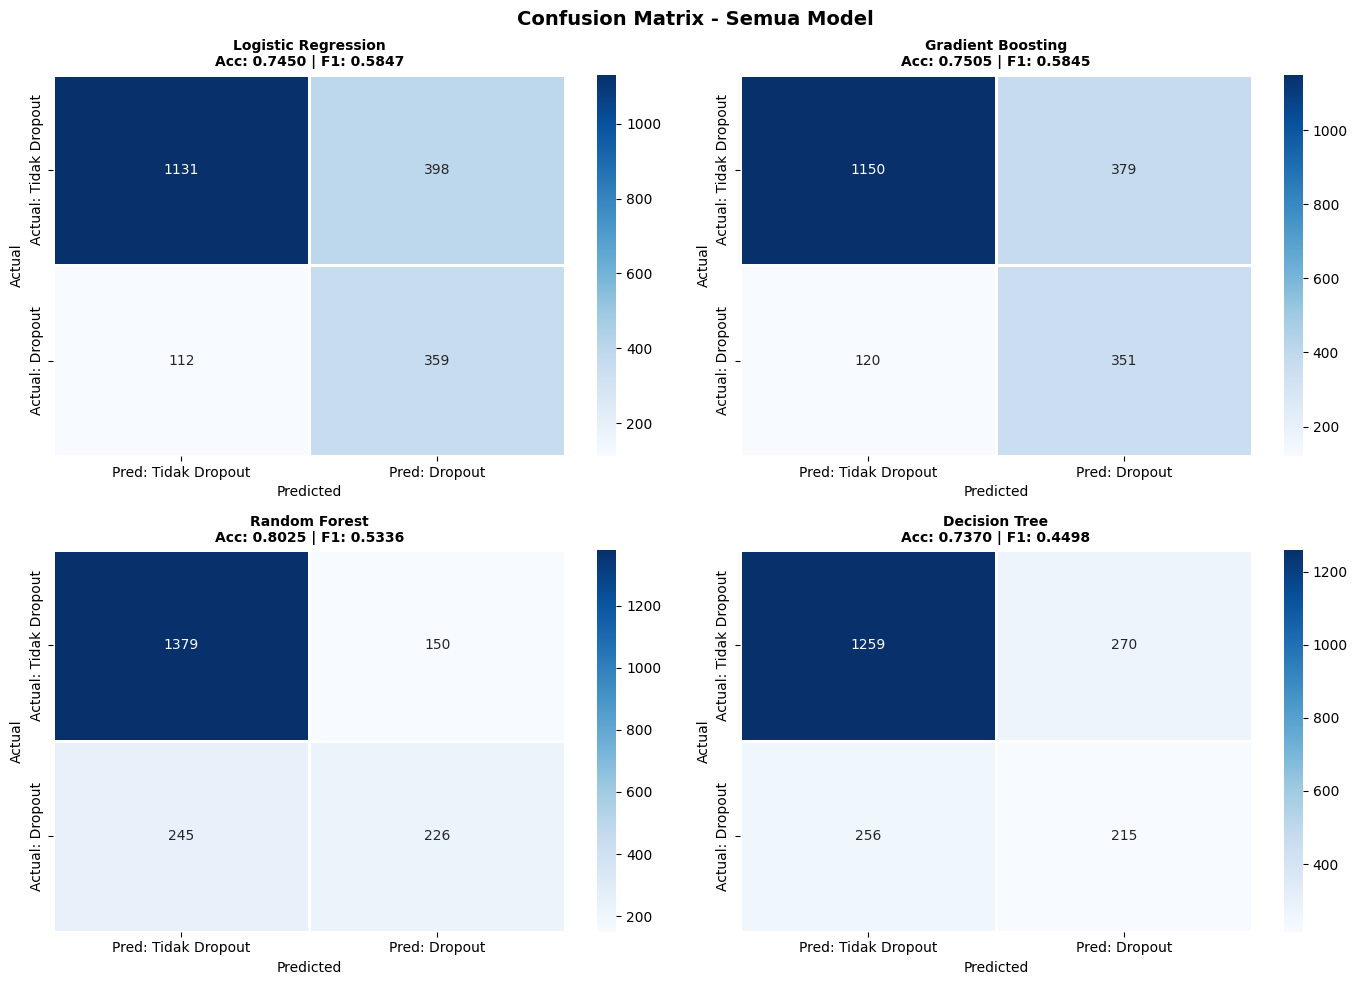

✅ Plot 7 - Confusion Matrix selesai!


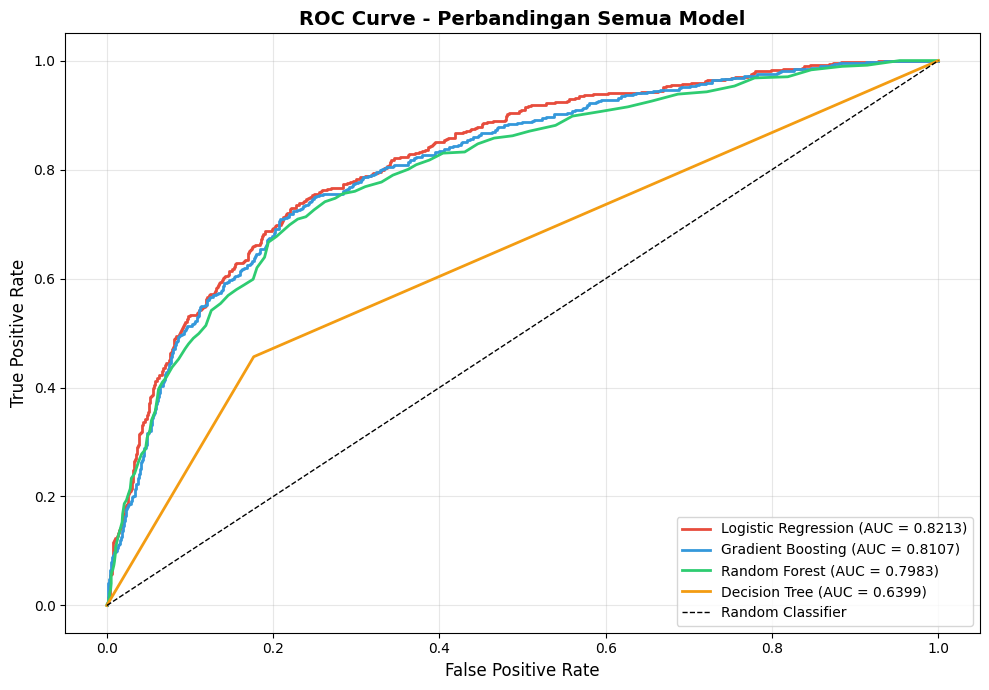

✅ Plot 8 - ROC Curve selesai!


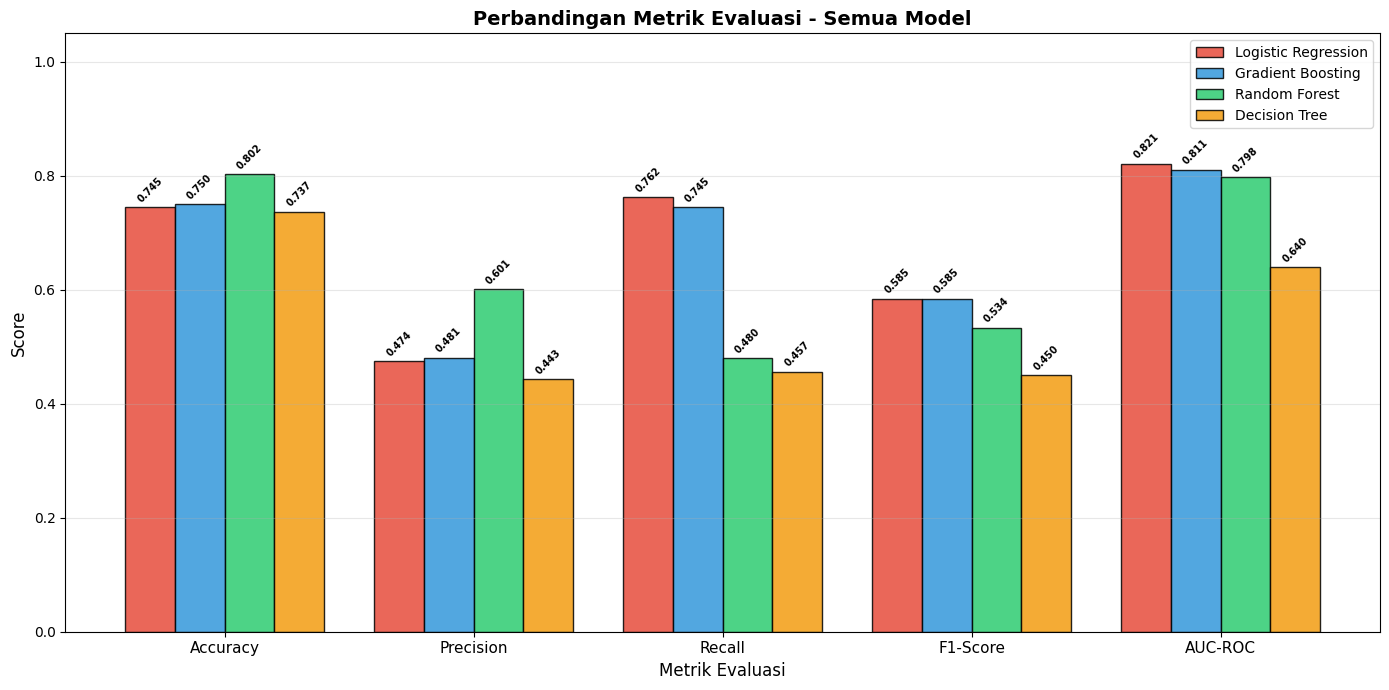

✅ Plot 9 - Perbandingan Metrik selesai!

🔍 FEATURE IMPORTANCE - Random Forest


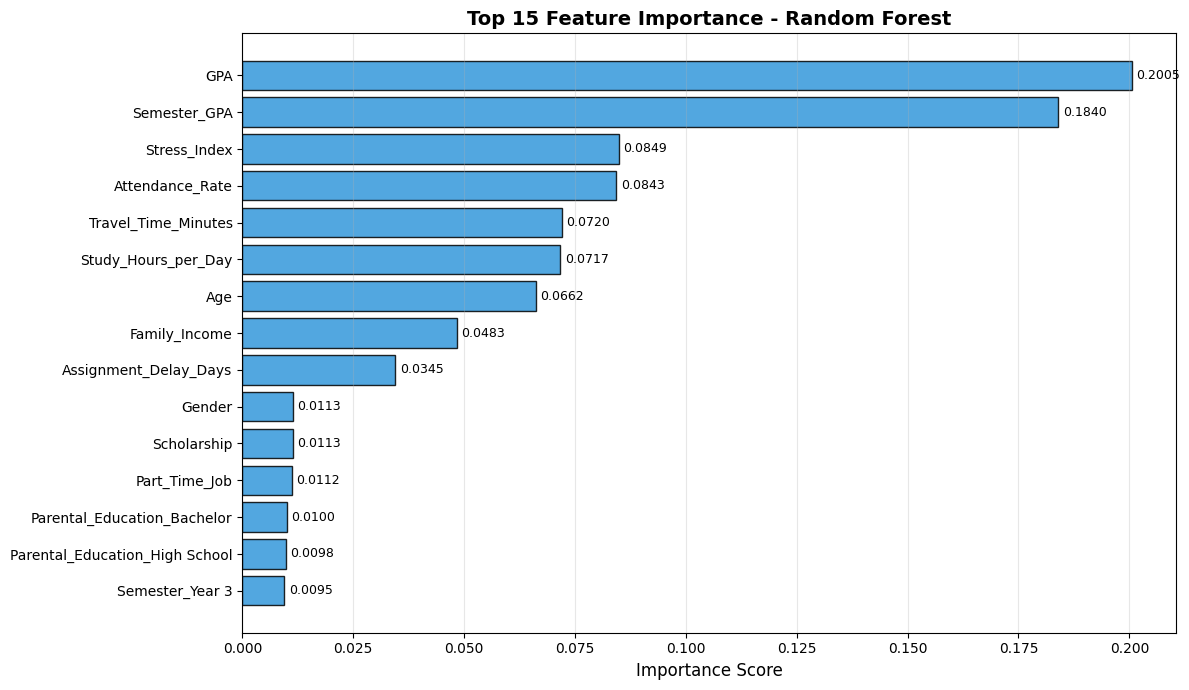


📋 Top 10 Fitur Terpenting:
   1. GPA                           : 0.2005
   2. Semester_GPA                  : 0.1840
   3. Stress_Index                  : 0.0849
   4. Attendance_Rate               : 0.0843
   5. Travel_Time_Minutes           : 0.0720
   6. Study_Hours_per_Day           : 0.0717
   7. Age                           : 0.0662
   8. Family_Income                 : 0.0483
   9. Assignment_Delay_Days         : 0.0345
  10. Gender                        : 0.0113

✅ Semua evaluasi selesai!
💾 10 plot tersimpan sebagai file PNG


In [12]:
# ============================================================
# STEP 7: EVALUASI LENGKAP - CONFUSION MATRIX & ROC CURVE
# ============================================================
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.metrics import roc_curve

print("=" * 60)
print("📊 EVALUASI LENGKAP - VISUALISASI")
print("=" * 60)

# --- 7.1 Confusion Matrix semua model ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Confusion Matrix - Semua Model', fontsize=14, fontweight='bold')
axes = axes.flatten()

model_order = ['Logistic Regression', 'Gradient Boosting',
               'Random Forest', 'Decision Tree']

for i, name in enumerate(model_order):
    model   = final_models[name]
    y_pred  = model.predict(X_test_scaled)
    cm      = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                ax=axes[i], linewidths=1,
                xticklabels=['Pred: Tidak Dropout','Pred: Dropout'],
                yticklabels=['Actual: Tidak Dropout','Actual: Dropout'])
    axes[i].set_title(f'{name}\nAcc: {final_results[name]["Accuracy"]:.4f} | '
                      f'F1: {final_results[name]["F1-Score"]:.4f}',
                      fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

plt.tight_layout()
plt.savefig('plot_07_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 7 - Confusion Matrix selesai!")

# --- 7.2 ROC Curve semua model ---
plt.figure(figsize=(10, 7))
colors_roc = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

for i, name in enumerate(model_order):
    model       = final_models[name]
    y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
    auc_val     = final_results[name]['AUC-ROC']
    plt.plot(fpr, tpr, color=colors_roc[i], linewidth=2,
             label=f'{name} (AUC = {auc_val:.4f})')

plt.plot([0,1],[0,1],'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Perbandingan Semua Model', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plot_08_roc_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 8 - ROC Curve selesai!")

# --- 7.3 Perbandingan Metrik Visual ---
metrics    = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
x          = np.arange(len(metrics))
width      = 0.2
colors_bar = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

fig, ax = plt.subplots(figsize=(14, 7))
for i, name in enumerate(model_order):
    vals = [final_results[name][m] for m in metrics]
    bars = ax.bar(x + i*width, vals, width, label=name,
                  color=colors_bar[i], alpha=0.85, edgecolor='black')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom',
                fontsize=7, fontweight='bold', rotation=45)

ax.set_xlabel('Metrik Evaluasi', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Perbandingan Metrik Evaluasi - Semua Model',
             fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_09_metrik_perbandingan.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Plot 9 - Perbandingan Metrik selesai!")

# --- 7.4 Feature Importance (Random Forest) ---
print("\n" + "=" * 60)
print("🔍 FEATURE IMPORTANCE - Random Forest")
print("=" * 60)

rf_model   = final_models['Random Forest']
importance = pd.DataFrame({
    'Feature'  : X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(12, 7))
bars = plt.barh(importance['Feature'][::-1],
                importance['Importance'][::-1],
                color='#3498db', edgecolor='black', alpha=0.85)
for bar, val in zip(bars, importance['Importance'][::-1]):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.xlabel('Importance Score', fontsize=12)
plt.title('Top 15 Feature Importance - Random Forest',
          fontsize=14, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('plot_10_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📋 Top 10 Fitur Terpenting:")
for idx, row in importance.head(10).iterrows():
    print(f"  {importance.index.get_loc(idx)+1:2}. {row['Feature']:<30}: {row['Importance']:.4f}")

print("\n✅ Semua evaluasi selesai!")
print(f"💾 10 plot tersimpan sebagai file PNG")

In [13]:
# ============================================================
# STEP 8.1: SIMPAN SEMUA OBJEK UNTUK DEPLOYMENT
# ============================================================
import joblib

# Simpan semua model
joblib.dump(trained_models['Logistic Regression'], 'model_lr.pkl')
joblib.dump(trained_models['Decision Tree'],       'model_dt.pkl')
joblib.dump(trained_models['Random Forest'],       'model_rf.pkl')
joblib.dump(trained_models['Gradient Boosting'],   'model_gb.pkl')

# Simpan scaler & feature names
joblib.dump(scaler,              'scaler.pkl')
joblib.dump(X.columns.tolist(),  'feature_names.pkl')

# Simpan hasil evaluasi & data bersih
joblib.dump(final_results,       'results.pkl')
joblib.dump(df_encoded,          'df_encoded.pkl')

# Simpan feature importance
importance_full = pd.DataFrame({
    'Feature'   : X.columns,
    'Importance': trained_models['Random Forest'].feature_importances_
}).sort_values('Importance', ascending=False)
joblib.dump(importance_full, 'feature_importance.pkl')

print("=" * 50)
print("💾 SEMUA OBJEK TERSIMPAN:")
print("=" * 50)
saved_files = [
    'model_lr.pkl', 'model_dt.pkl',
    'model_rf.pkl', 'model_gb.pkl',
    'scaler.pkl', 'feature_names.pkl',
    'results.pkl', 'df_encoded.pkl',
    'feature_importance.pkl'
]
for f in saved_files:
    print(f"  ✅ {f}")

print(f"\n📁 Total file tersimpan: {len(saved_files)}")
print("✅ Siap untuk deployment Streamlit!")

💾 SEMUA OBJEK TERSIMPAN:
  ✅ model_lr.pkl
  ✅ model_dt.pkl
  ✅ model_rf.pkl
  ✅ model_gb.pkl
  ✅ scaler.pkl
  ✅ feature_names.pkl
  ✅ results.pkl
  ✅ df_encoded.pkl
  ✅ feature_importance.pkl

📁 Total file tersimpan: 9
✅ Siap untuk deployment Streamlit!


In [16]:
df_clean.head(20)

,Age,Gender,Family_Income,Internet_Access,Study_Hours_per_Day,Attendance_Rate,Assignment_Delay_Days,Travel_Time_Minutes,Part_Time_Job,Scholarship,Stress_Index,GPA,Semester_GPA,Semester,Department,Parental_Education,Dropout
0,22.1,Male,25000.0,Yes,3.36,86.1,2,20.4,Yes,No,5.5,0.96,0.90,Year 1,Arts,High School,0
1,20.7,Male,25000.0,Yes,4.30,68.0,2,44.0,No,No,6.8,1.28,1.20,Year 3,Engineering,Bachelor,1
2,22.4,Male,40183.0,Yes,4.40,70.9,0,48.9,Yes,No,5.5,1.68,1.32,Year 1,Arts,Master,0
3,24.4,Male,29740.5,Yes,4.00,82.2,2,38.6,No,No,5.5,1.78,1.77,Year 1,CS,High School,1
4,20.5,Female,25319.0,Yes,4.19,75.7,1,23.0,No,No,7.0,1.48,0.91,Year 4,Business,Bachelor,0
5,20.5,Male,25000.0,Yes,4.11,89.1,2,47.1,No,Yes,6.0,2.52,2.72,Year 3,Business,Bachelor,0
6,24.5,Male,25000.0,Yes,3.00,78.2,1,37.4,Yes,Yes,7.3,0.64,0.33,Year 4,CS,Bachelor,0
7,22.7,Female,25000.0,Yes,2.12,86.4,1,34.0,No,Yes,6.5,1.79,1.14,Year 1,Arts,High School,0
8,20.0,Male,57413.0,Yes,4.07,97.5,3,52.1,No,No,4.2,3.08,2.81,Year 1,CS,High School,0
9,22.2,Female,44930.0,Yes,2.98,82.2,1,19.7,No,No,6.7,1.59,1.73,Year 1,Science,Master,0
